# 🔄 Versioning in Machine Learning & MLOps

## Git → DVC → MLflow

### Why Versioning Matters?

In a Machine Learning project, three things change continuously:

1. 💻 **Code** – preprocessing, feature engineering, training logic
2. 📊 **Data** – datasets, features, training/validation data
3. 🤖 **Models** – trained models, parameters, metrics, artifacts

If we do not version these components, it becomes difficult to answer:

> **"Which code + which data + which parameters produced this model?"**

Versioning provides **traceability, reproducibility, collaboration, and rollback**.

---

# 🧩 The Three Layers of Versioning

| Component | What is Versioned? | Tool |
|---|---|---|
| 💻 Code | Source code, configuration, notebooks | **Git** |
| 📊 Data | Datasets and data changes | **DVC** |
| 🤖 Model | Models, parameters, metrics, artifacts | **MLflow** |

### Simple MLOps View

```text
                  MACHINE LEARNING PROJECT
                           │
          ┌────────────────┼────────────────┐
          │                │                │
          ▼                ▼                ▼
      💻 CODE           📊 DATA          🤖 MODEL
          │                │                │
         Git              DVC            MLflow
          │                │                │
          ▼                ▼                ▼
     Code Version      Data Version    Model Version
          │                │                │
          └────────────────┼────────────────┘
                           ▼
                  Reproducible ML System

# Classification with Tree-based Model and MLflow

This notebook demonstrates loading a synthetic classification dataset, training a RandomForest classifier, and logging the model with MLflow.


In [ ]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import mlflow
import mlflow.sklearn


## 📦 Load Dataset & Display Samples

In [ ]:
# Load the Online Retail dataset
dataset = pd.read_excel("./online_retail.xlsx")

# Basic dataset overview
print(f"Dataset Shape: {dataset.shape[0]} rows × {dataset.shape[1]} columns")
print(f"\nColumn Names: {list(dataset.columns)}")
print(f"\nData Types:")
print(dataset.dtypes)

# Display first 10 samples
print("\n" + "=" * 80)
print("FIRST 10 SAMPLES")
print("=" * 80)
dataset.head(10)

## 🔍 Exploratory Data Analysis (EDA)

In [ ]:
# ──────────────────────────────────────────────
# 1. Statistical Summary (Numerical Columns)
# ──────────────────────────────────────────────
print("=" * 80)
print("📊 STATISTICAL SUMMARY (Numerical Columns)")
print("=" * 80)
dataset.describe()

In [ ]:
# ──────────────────────────────────────────────
# 2. Missing Values Analysis
# ──────────────────────────────────────────────
print("=" * 80)
print("🕳️  MISSING VALUES ANALYSIS")
print("=" * 80)

missing = dataset.isnull().sum()
missing_pct = (missing / len(dataset) * 100).round(2)
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).sort_values('Missing Count', ascending=False)

print(missing_df)
print(f"\nTotal Missing Values: {missing.sum()}")
print(f"Total Missing %: {(missing.sum() / (len(dataset) * len(dataset.columns)) * 100):.2f}%")

In [ ]:
# ──────────────────────────────────────────────
# 3. Unique Values Per Column
# ──────────────────────────────────────────────
print("=" * 80)
print("🔢 UNIQUE VALUES PER COLUMN")
print("=" * 80)

unique_df = pd.DataFrame({
    'Unique Count': dataset.nunique(),
    'Dtype': dataset.dtypes
})
print(unique_df)

In [ ]:
# ──────────────────────────────────────────────
# 4. Top 10 Countries by Transactions
# ──────────────────────────────────────────────
print("=" * 80)
print("🌍 TOP 10 COUNTRIES BY NUMBER OF TRANSACTIONS")
print("=" * 80)
country_counts = dataset['Country'].value_counts().head(10)
print(country_counts)
print(f"\nTotal unique countries: {dataset['Country'].nunique()}")

In [ ]:
# ──────────────────────────────────────────────
# 5. Top 10 Most Sold Products
# ──────────────────────────────────────────────
print("=" * 80)
print("🛒 TOP 10 MOST SOLD PRODUCTS (by frequency)")
print("=" * 80)
print(dataset['Description'].value_counts().head(10))

In [ ]:
# ──────────────────────────────────────────────
# 6. Check for Duplicate Rows
# ──────────────────────────────────────────────
print("=" * 80)
print("📋 DUPLICATE ROWS CHECK")
print("=" * 80)
duplicates = dataset.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")
print(f"Duplicate rows %: {(duplicates / len(dataset) * 100):.2f}%")

In [ ]:
# ──────────────────────────────────────────────
# 7. Negative Quantities (Cancelled Orders)
# ──────────────────────────────────────────────
print("=" * 80)
print("❌ NEGATIVE QUANTITIES (Possible Cancelled/Returned Orders)")
print("=" * 80)
neg_qty = dataset[dataset['Quantity'] < 0]
print(f"Rows with negative quantity: {len(neg_qty)}")
print(f"Negative quantity %: {(len(neg_qty) / len(dataset) * 100):.2f}%")
print(f"\nSample cancelled/returned orders:")
neg_qty.head(5)

In [ ]:
# ──────────────────────────────────────────────
# 8. Dataset Info Summary
# ──────────────────────────────────────────────
print("=" * 80)
print("ℹ️  DATASET INFO")
print("=" * 80)
dataset.info()

---

## 🧹 Data Preprocessing

1. Remove duplicate rows
2. Remove rows with negative `Quantity` (cancelled/returned orders)
3. Create a binary classification target: **High-Value Transaction** (`TotalAmount > median`)
4. Missing values will be handled inside the sklearn Pipeline:
   - **Numerical** columns → impute with **median**
   - **Categorical** columns → impute with **mode**

In [ ]:
# ──────────────────────────────────────────────
# Step 1: Remove Duplicate Rows
# ──────────────────────────────────────────────
print(f"Before removing duplicates: {dataset.shape[0]} rows")
dataset = dataset.drop_duplicates()
print(f"After removing duplicates:  {dataset.shape[0]} rows")
print(f"Duplicates removed: {541909 - dataset.shape[0]}")

In [ ]:
# ──────────────────────────────────────────────
# Step 2: Remove Rows with Negative Quantity
# ──────────────────────────────────────────────
print(f"Before removing negative quantities: {dataset.shape[0]} rows")
dataset = dataset[dataset['Quantity'] > 0]
print(f"After removing negative quantities:  {dataset.shape[0]} rows")
print(f"\nDataset shape after cleaning: {dataset.shape}")

In [ ]:
# ──────────────────────────────────────────────
# Step 3: Feature Engineering — Create Target Variable
# ──────────────────────────────────────────────

# Create TotalAmount = Quantity × UnitPrice
dataset['TotalAmount'] = dataset['Quantity'] * dataset['UnitPrice']

# Binary target: 1 if TotalAmount > median (High-Value), 0 otherwise (Low-Value)
median_amount = dataset['TotalAmount'].median()
dataset['HighValue'] = (dataset['TotalAmount'] > median_amount).astype(int)

print(f"Median TotalAmount: {median_amount}")
print(f"\nTarget Variable Distribution:")
print(dataset['HighValue'].value_counts())
print(f"\nTarget Ratio: {dataset['HighValue'].value_counts(normalize=True).round(4).to_dict()}")

In [ ]:
# ──────────────────────────────────────────────
# Step 4: Select Features & Split Data
# ──────────────────────────────────────────────

# Define feature columns
numerical_features = ['Quantity', 'UnitPrice']
categorical_features = ['Country']

feature_columns = numerical_features + categorical_features

X = dataset[feature_columns]
y = dataset['HighValue']

# Train/Test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"y_train distribution:\n{y_train.value_counts()}")
print(f"\ny_test distribution:\n{y_test.value_counts()}")

---

## 🔧 Define Preprocessing + Model Pipeline

Using sklearn `Pipeline` and `ColumnTransformer` to handle:
- **Numerical**: `SimpleImputer(strategy='median')` → `StandardScaler`
- **Categorical**: `SimpleImputer(strategy='most_frequent')` → `OneHotEncoder`
- **Classifier**: `RandomForestClassifier`

In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, f1_score, precision_score, recall_score

# ──────────────────────────────────────────────
# Numerical Transformer: Impute (median) → Scale
# ──────────────────────────────────────────────
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# ──────────────────────────────────────────────
# Categorical Transformer: Impute (mode) → OneHotEncode
# ──────────────────────────────────────────────
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# ──────────────────────────────────────────────
# ColumnTransformer: Combine numerical + categorical
# ──────────────────────────────────────────────
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

# ──────────────────────────────────────────────
# Full Pipeline: Preprocessing → RandomForest
# ──────────────────────────────────────────────
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

print("✅ Pipeline defined successfully!")
print(pipeline)

---

## 🧪 MLflow Experiment: Hyperparameter Tuning & Model Logging

1. Set MLflow experiment name: **"RF model versioning demo"**
2. Run `GridSearchCV` for hyperparameter tuning
3. Log the **best model**, its parameters, and metrics to MLflow
4. Log **confusion matrix as image** artifact
5. Log **best params as CSV** artifact
6. Print the best model **run ID**

In [ ]:
# ──────────────────────────────────────────────
# Set MLflow Experiment Name
# ──────────────────────────────────────────────
experiment_name = "RF model versioning demo"
mlflow.set_experiment(experiment_name)

print(f"✅ MLflow experiment set: '{experiment_name}'")

In [ ]:
# ──────────────────────────────────────────────
# Define Hyperparameter Grid
# ──────────────────────────────────────────────
param_grid = {
    'classifier__n_estimators': [50, 100, 200],
    'classifier__max_depth': [5, 10, 20, None],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf': [1, 2, 4]
}

print("Hyperparameter Grid:")
for param, values in param_grid.items():
    print(f"  {param}: {values}")

# ──────────────────────────────────────────────
# Run GridSearchCV
# ──────────────────────────────────────────────
print("\n🔄 Running GridSearchCV (this may take a few minutes)...")

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

grid_search.fit(X_train, y_train)

print(f"\n✅ GridSearchCV complete!")
print(f"Best CV Accuracy: {grid_search.best_score_:.4f}")
print(f"\nBest Parameters:")
for param, value in grid_search.best_params_.items():
    print(f"  {param}: {value}")

In [19]:
# ──────────────────────────────────────────────
# Evaluate Best Model on Test Set
# ──────────────────────────────────────────────
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

test_accuracy = accuracy_score(y_test, y_pred)
test_f1 = f1_score(y_test, y_pred, average='weighted')
test_precision = precision_score(y_test, y_pred, average='weighted')
test_recall = recall_score(y_test, y_pred, average='weighted')

print("=" * 80)
print("📊 BEST MODEL - TEST SET EVALUATION")
print("=" * 80)
print(f"Test Accuracy:  {test_accuracy:.4f}")
print(f"Test F1 Score:  {test_f1:.4f}")
print(f"Test Precision: {test_precision:.4f}")
print(f"Test Recall:    {test_recall:.4f}")
print(f"\n{classification_report(y_test, y_pred, target_names=['Low-Value', 'High-Value'])}")

📊 BEST MODEL - TEST SET EVALUATION
Test Accuracy:  0.9999
Test F1 Score:  0.9999
Test Precision: 0.9999
Test Recall:    0.9999

              precision    recall  f1-score   support

   Low-Value       1.00      1.00      1.00     52738
  High-Value       1.00      1.00      1.00     52473

    accuracy                           1.00    105211
   macro avg       1.00      1.00      1.00    105211
weighted avg       1.00      1.00      1.00    105211



2026/10/02 18:49:55 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/10/02 18:49:55 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


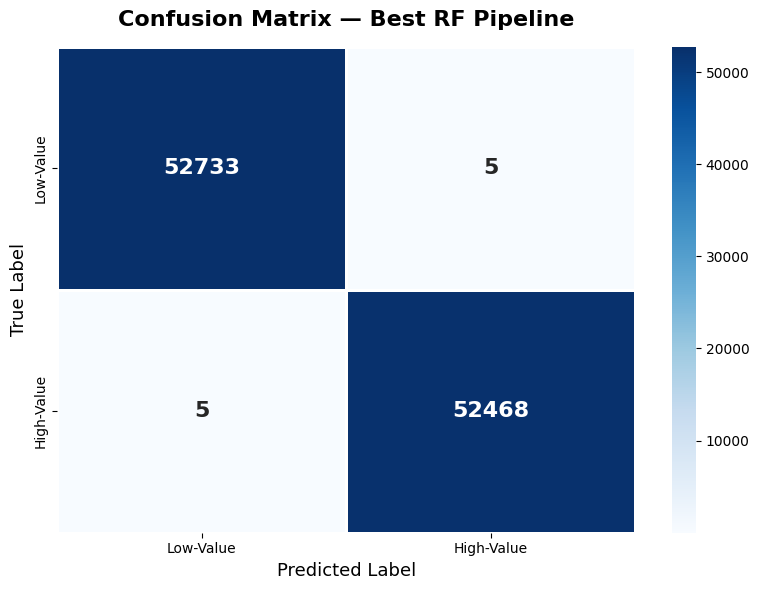

✅ Confusion matrix image logged to MLflow: plots/confusion_matrix.png
✅ Best params CSV logged to MLflow: params/best_params.csv

── Best Params CSV Content ──


,Parameter,Best Value
0,classifier__max_depth,NaN
1,classifier__min_samples_leaf,1.0000
2,classifier__min_samples_split,2.0000
3,classifier__n_estimators,50.0000
4,cv_accuracy,0.9999
5,test_accuracy,0.9999
6,test_f1_score,0.9999
7,test_precision,0.9999
8,test_recall,0.9999



✅ BEST MODEL LOGGED TO MLFLOW SUCCESSFULLY!
Experiment Name:  RF model versioning demo
Run Name:         best_rf_pipeline
Best Run ID:      e92368539ff94b94a7f3d6356f2b3759

Artifacts logged:
  📦 Model:            best_rf_pipeline_model/
  🖼️  Confusion Matrix: plots/confusion_matrix.png
  📄 Best Params CSV:  params/best_params.csv


In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import os
import tempfile

# ──────────────────────────────────────────────
# Log Best Model to MLflow
# ──────────────────────────────────────────────
with mlflow.start_run(run_name='best_rf_pipeline') as run:

    # ── 1. Log best hyperparameters ──
    for param, value in grid_search.best_params_.items():
        mlflow.log_param(param, value)

    # ── 2. Log cross-validation score ──
    mlflow.log_metric('cv_accuracy', grid_search.best_score_)

    # ── 3. Log test set metrics ──
    mlflow.log_metric('test_accuracy', test_accuracy)
    mlflow.log_metric('test_f1_score', test_f1)
    mlflow.log_metric('test_precision', test_precision)
    mlflow.log_metric('test_recall', test_recall)

    # ── 4. Log the best pipeline model ──
    mlflow.sklearn.log_model(best_model, 'best_rf_pipeline_model')

    # ── 5. Log Confusion Matrix as Image Artifact ──
    cm = confusion_matrix(y_test, y_pred)
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=['Low-Value', 'High-Value'],
        yticklabels=['Low-Value', 'High-Value'],
        linewidths=1, linecolor='white',
        annot_kws={'fontsize': 16, 'fontweight': 'bold'},
        ax=ax
    )
    ax.set_title('Confusion Matrix — Best RF Pipeline', fontsize=16, fontweight='bold', pad=15)
    ax.set_xlabel('Predicted Label', fontsize=13)
    ax.set_ylabel('True Label', fontsize=13)
    plt.tight_layout()

    # Save to a temp file and log as artifact
    cm_path = os.path.join(tempfile.gettempdir(), 'confusion_matrix.png')
    fig.savefig(cm_path, dpi=150, bbox_inches='tight')
    plt.show()
    mlflow.log_artifact(cm_path, 'plots')
    print(f'✅ Confusion matrix image logged to MLflow: plots/confusion_matrix.png')

    # ── 6. Log Best Params as CSV Artifact ──
    best_params_df = pd.DataFrame({
        'Parameter': list(grid_search.best_params_.keys()),
        'Best Value': list(grid_search.best_params_.values())
    })
    # Also add metrics to the CSV for a complete summary
    metrics_rows = pd.DataFrame({
        'Parameter': ['cv_accuracy', 'test_accuracy', 'test_f1_score', 'test_precision', 'test_recall'],
        'Best Value': [
            round(grid_search.best_score_, 4),
            round(test_accuracy, 4),
            round(test_f1, 4),
            round(test_precision, 4),
            round(test_recall, 4)
        ]
    })
    full_summary_df = pd.concat([best_params_df, metrics_rows], ignore_index=True)

    csv_path = os.path.join(tempfile.gettempdir(), 'best_params.csv')
    full_summary_df.to_csv(csv_path, index=False)
    mlflow.log_artifact(csv_path, 'params')
    print(f'✅ Best params CSV logged to MLflow: params/best_params.csv')
    print(f'\n── Best Params CSV Content ──')
    display(full_summary_df)

    # ── 7. Log additional metadata as tags ──
    mlflow.set_tag('model_type', 'RandomForestClassifier')
    mlflow.set_tag('pipeline', 'preprocessor + classifier')
    mlflow.set_tag('tuning_method', 'GridSearchCV')
    mlflow.set_tag('dataset', 'online_retail')

    best_run_id = run.info.run_id

print("\n" + "=" * 80)
print("✅ BEST MODEL LOGGED TO MLFLOW SUCCESSFULLY!")
print("=" * 80)
print(f"Experiment Name:  {experiment_name}")
print(f"Run Name:         best_rf_pipeline")
print(f"Best Run ID:      {best_run_id}")
print(f"\nArtifacts logged:")
print(f"  📦 Model:            best_rf_pipeline_model/")
print(f"  🖼️  Confusion Matrix: plots/confusion_matrix.png")
print(f"  📄 Best Params CSV:  params/best_params.csv")
print("=" * 80)